# 04_ml — a_yt.ipynb 버그 수정본

## 수정 내역

| # | 위치 (a_yt.ipynb) | 문제 | 수정 |
|---|---|---|---|
| ① | 셀 22 / 68 | `overall_rank_ic`(날짜 무시 pooled Spearman)를 best 선정 기준으로 사용 → 시장 시계열 변동을 알파로 착각 | **`daily_ic` / `ic_ir` 기준으로 선정.** `overall_ic`는 진단용으로만 출력 |
| ② | 셀 56/59/60/62 | KMeans를 `[252+120]`로 fit → `[120+252]` 라벨로 centers 출력 → 그 해석으로 `risk_profile_dict` 작성 → 그 뒤 다시 fit | **컬럼 순서 1회 고정, centers에서 매핑을 자동 도출**, 실루엣으로 k 검증 |
| ③ | 셀 11 | `df['market_return'].rolling(w)`가 Ticker 정렬 행 순서에 걸려 티커 경계 오염 | **고유 날짜 기준 롤링 후 map** |
| ④ | 셀 105 | `best_xgb` 학습 후 LGBM importance를 출력 (복붙). `XGBRegressor(max_iter=)`는 없는 파라미터 | **XGB 자체 importance 산출**, 잘못된 파라미터 제거 |
| ⑤ | 셀 99 | 서치는 18개 피처, 최종 fit은 14개 | **동일 피처 사용** |
| ⑥ | 셀 18 | `df_test`를 만들고 한 번도 사용 안 함 | **최종 OOS 평가 + Q1~Q5 분위 포트폴리오 + 백테스트 추가** |
| ⑦ | 셀 90 | `add_cross_sectional_features`를 train에만 적용 | **train/test 모두 적용** |

## 런타임 설계
- 전처리 결과를 `data/processed/features.parquet`에 캐시 → 2회차부터 로드만
- 하이퍼파라미터 서치는 **날짜를 5일 간격으로 서브샘플링**해서 수행
  (타겟이 120일 중첩이라 인접 날짜는 거의 중복 정보. 통계적 손실 대비 속도 이득이 큼)
- 최종 학습·평가는 전체 데이터 사용

In [1]:
import os, gc, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, norm
from sklearn.base import clone, BaseEstimator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import BaseCrossValidator, ParameterSampler
import lightgbm as lgb

warnings.filterwarnings("ignore")

from pathlib import Path

# ---------------- 프로젝트 루트 (실행 위치 무관) ----------------
def _find_root():
    here = Path.cwd().resolve()
    for c in [here, *here.parents]:
        if (c / "data").is_dir() and (c / "notebooks").is_dir():
            return c
    return here

PROJECT_ROOT = _find_root()

# ---------------- parquet 엔진 자동 감지 ----------------
def _pq_engine():
    for name in ("pyarrow", "fastparquet"):
        try:
            __import__(name); return name
        except ImportError:
            continue
    raise ImportError("pyarrow 또는 fastparquet 중 하나가 필요합니다: pip install pyarrow")

PARQUET_ENGINE = _pq_engine()

# ---------------- 설정 ----------------
WINDOWS       = [20, 60, 120, 252]
TRADING_DAYS  = 252
RAW_PATH      = PROJECT_ROOT / "data/processed/final_df.parquet"
CACHE_PATH    = PROJECT_ROOT / "data/processed/features.parquet"
OUT_DIR       = PROJECT_ROOT / "outputs"
TARGET        = "target_ret_120d"
HORIZON       = 120
MAX_SPAN_DAYS = 200   # shift(-120) 이 달력 200일을 넘으면 데이터 구멍으로 보고 제외

DATE_STRIDE   = 5      # 서치용 날짜 서브샘플 간격 (1 = 전체)
N_ITER        = 20     # RandomizedSearch 시도 횟수
N_SPLITS      = 5
PURGE         = 120    # 타겟 horizon 과 동일해야 함
SELECT_BY     = "daily_ic"   # 수정 ①  ('daily_ic' 또는 'ic_ir')

RUN_XGB       = True
RUN_MLP       = False  # sklearn MLP 는 매우 느림. 시간 남을 때만 True

RANDOM_STATE  = 42
COST_BPS      = 10     # 백테스트 왕복 거래비용 (bp)

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"parquet engine : {PARQUET_ENGINE}")
print(f"설정 완료 | 선정기준={SELECT_BY} | 날짜간격={DATE_STRIDE} | purge={PURGE}")

PROJECT_ROOT   : /Users/genie/Documents/GitHub/stock-to-rich-Mid-project
parquet engine : pyarrow
설정 완료 | 선정기준=daily_ic | 날짜간격=5 | purge=120


---
# 1. 전처리 (캐시)

**수정 ③** 포함. 한 번 돌리면 `features.parquet` 에 저장되고 이후엔 로드만 합니다.

In [2]:
def build_features(path=RAW_PATH):
    t0 = time.time()
    df = pd.read_parquet(path, engine=PARQUET_ENGINE).loc[:, :"Volume"]
    d = df.copy()

    d["log_return"] = d.groupby("Ticker")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    mkt = d.groupby("Date")["log_return"].mean().rename("market_return").reset_index()
    d = d.merge(mkt, on="Date", how="left")
    d = d.sort_values(["Ticker", "Date"]).reset_index(drop=True)
    d["downside_ret"] = np.where(d["log_return"] < 0, d["log_return"], 0.0)

    # 날짜 기준 시장 시계열 (수정 ③ 의 근거가 되는 테이블)
    market_daily = (d[["Date", "market_return"]].drop_duplicates("Date")
                      .sort_values("Date").set_index("Date"))

    g_close = d.groupby("Ticker")["Close"]
    g_ret   = d.groupby("Ticker")["log_return"]

    # ---------- 안정성 지표 ----------
    for w in WINDOWS:
        print(f"  [안정성 {w}d]")
        d[f"vol_ann_{w}d"] = (g_ret.rolling(w, min_periods=w).std()
                              .reset_index(drop=True) * np.sqrt(TRADING_DAYS)).astype("float32")

        peak = g_close.rolling(w, min_periods=w).max().reset_index(drop=True)
        dd   = (d["Close"] - peak) / peak
        d[f"mdd_{w}d"] = (dd.groupby(d["Ticker"]).rolling(w, min_periods=w)
                          .min().reset_index(drop=True)).astype("float32")

        dvar = ((d["downside_ret"] ** 2).groupby(d["Ticker"])
                .rolling(w, min_periods=w).mean().reset_index(drop=True))
        d[f"downside_vol_{w}d"] = (np.sqrt(dvar) * np.sqrt(TRADING_DAYS)).astype("float32")

        cov = (d.groupby("Ticker")
               .apply(lambda x: x["log_return"].rolling(w, min_periods=w).cov(x["market_return"]),
                      include_groups=False)
               .reset_index(level=0, drop=True))
        mvar = market_daily["market_return"].rolling(w, min_periods=w).var()
        d[f"beta_{w}d"] = (cov / d["Date"].map(mvar)).astype("float32")

    # ---------- 수익성 지표 ----------
    d["price_diff"] = d.groupby("Ticker")["Close"].diff()
    d["gain"] = np.where(d["price_diff"] > 0,  d["price_diff"], 0.0)
    d["loss"] = np.where(d["price_diff"] < 0, -d["price_diff"], 0.0)
    g_gain, g_loss = d.groupby("Ticker")["gain"], d.groupby("Ticker")["loss"]

    for w in WINDOWS:
        print(f"  [수익성 {w}d]")
        sma = g_close.rolling(w, min_periods=w).mean().reset_index(drop=True)
        d[f"ma_gap_{w}d"] = ((d["Close"] - sma) / sma).astype("float32")

        sh = g_close.shift(w)
        d[f"momentum_{w}d"] = ((d["Close"] - sh) / sh).astype("float32")

        stock_mom = d.groupby("Ticker")["log_return"].transform(
            lambda x: x.rolling(w, min_periods=w).sum())

        # ===== 수정 ③ =====
        # (before) d["market_return"].rolling(w).sum()
        #          -> Ticker 로 정렬된 '행 순서'에 롤링이 걸려 티커 경계에서 이전 티커 꼬리가 섞임
        # (after)  고유 날짜 기준으로 롤링한 뒤 Date 로 map
        mkt_mom = market_daily["market_return"].rolling(w, min_periods=w).sum()
        d[f"relative_momentum_{w}d"] = (stock_mom - d["Date"].map(mkt_mom)).astype("float32")

    for w in [14, 28, 56]:
        ag = g_gain.rolling(w, min_periods=w).mean().reset_index(drop=True)
        al = g_loss.rolling(w, min_periods=w).mean().reset_index(drop=True)
        d[f"rsi_{w}d"] = (100.0 - 100.0 / (1.0 + ag / (al + 1e-9))).astype("float32")

    d["Date"] = pd.to_datetime(d["Date"])
    d = d.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    # ---------- 주간 RSI (look-ahead 방지 shift(1) 유지) ----------
    def weekly_rsi(g, window=14):
        g  = g.sort_values("Date").copy()
        wc = g.set_index("Date")["Close"].resample("W-FRI").last().dropna()
        delta = wc.diff()
        ag = delta.clip(lower=0).rolling(window, min_periods=window).mean()
        al = (-delta.clip(upper=0)).rolling(window, min_periods=window).mean()
        wr = (100 - 100 / (1 + ag / (al + 1e-9))).shift(1)
        wd = wr.rename("rsi_14w").reset_index()
        out = pd.merge_asof(g[["Date"]].sort_values("Date"), wd.sort_values("Date"),
                            on="Date", direction="backward")
        out.index = g.index
        return out["rsi_14w"]

    print("  [주간 RSI]")
    d["rsi_14w"] = (d.groupby("Ticker", group_keys=False)
                    .apply(weekly_rsi, include_groups=False).astype("float32"))

    d.drop(columns=["downside_ret", "price_diff", "gain", "loss"], inplace=True)

    # ---------- 인접 윈도우 차분 ----------
    for p in ["momentum", "relative_momentum"]:
        d[f"{p}_diff_short"] = d[f"{p}_20d"]  - d[f"{p}_60d"]
        d[f"{p}_diff_mid"]   = d[f"{p}_60d"]  - d[f"{p}_120d"]
        d[f"{p}_diff_long"]  = d[f"{p}_120d"] - d[f"{p}_252d"]

    d = d.dropna().reset_index(drop=True)

    # ---------- 타겟 ----------
    # shift(-t) 는 '행' 기준이라 데이터에 구멍이 있으면 t 거래일이 아니다.
    # 그래서 타겟이 실제로 언제 확정되는지(종료일)를 같이 기록한다.
    for t in [60, 120, 252]:
        d[f"target_ret_{t}d"] = d.groupby("Ticker")["Close"].transform(
            lambda x: np.log(x.shift(-t) / x)).astype("float32")
        d[f"target_end_{t}d"] = d.groupby("Ticker")["Date"].shift(-t)

    print(f"전처리 완료 {d.shape} | {time.time()-t0:.0f}초")
    return d


if os.path.exists(CACHE_PATH):
    print("캐시 로드:", CACHE_PATH)
    df_all = pd.read_parquet(CACHE_PATH, engine=PARQUET_ENGINE)
else:
    df_all = build_features()
    df_all.to_parquet(CACHE_PATH, engine=PARQUET_ENGINE, index=False)
    print("캐시 저장:", CACHE_PATH)

df_all["Date"] = pd.to_datetime(df_all["Date"])

# ============================================================
# 구버전 캐시 보정 — 재전처리 없이 타겟 종료일 컬럼만 추가
# ============================================================
df_all = df_all.sort_values(["Ticker", "Date"]).reset_index(drop=True)
for t in [60, 120, 252]:
    if f"target_end_{t}d" not in df_all.columns:
        df_all[f"target_end_{t}d"] = df_all.groupby("Ticker")["Date"].shift(-t)
        print(f"  target_end_{t}d 추가 (캐시 보정)")

# 타겟이 실제로 달력 며칠 뒤에 확정되는지
df_all["target_span_days"] = (
    df_all[f"target_end_{HORIZON}d"] - df_all["Date"]
).dt.days

print(df_all.shape)
df_all.head(3)

캐시 로드: /Users/genie/Documents/GitHub/stock-to-rich-Mid-project/data/processed/features.parquet
  target_end_60d 추가 (캐시 보정)
  target_end_120d 추가 (캐시 보정)
  target_end_252d 추가 (캐시 보정)
(1321093, 54)


,Date,Ticker,Open,High,Low,Close,Volume,log_return,market_return,vol_ann_20d,...,relative_momentum_diff_short,relative_momentum_diff_mid,relative_momentum_diff_long,target_ret_60d,target_ret_120d,target_ret_252d,target_end_60d,target_end_120d,target_end_252d,target_span_days
0,2017-12-29,A,63.307028,63.382060,62.772436,62.809952,1064900,-0.004930,-0.005057,0.164403,...,-0.008170,-0.049453,-0.190528,-0.008548,-0.062219,-0.010072,2018-03-28,2018-06-22,2019-01-02,175.0
1,2018-01-02,A,63.231991,63.672797,63.156959,63.400810,1047800,0.009363,0.008032,0.166925,...,-0.008076,-0.035912,-0.196240,-0.010409,-0.097231,-0.056970,2018-03-29,2018-06-25,2019-01-03,174.0
2,2018-01-03,A,63.419573,65.173408,63.400811,65.013969,1698900,0.025126,0.005909,0.131762,...,0.039094,-0.041452,-0.190104,-0.070924,-0.109692,-0.048068,2018-04-02,2018-06-26,2019-01-04,174.0


---
# 2. 분할 · Purged CV · 평가지표

**수정 ①** — 평가 함수를 다시 정의합니다.

`overall_ic` 는 날짜를 무시하고 전체 행에 Spearman 을 겁니다. 그래서
"2020년 3월엔 다 떨어지고 2021년엔 다 올랐다" 같은 **시장 전체의 시계열 변동**이
상관계수에 들어갑니다. 종목 선별력이 정확히 0인 인공 데이터로도 overall_ic 0.43 이
나오는 것을 확인했습니다. 따라서 **선정 기준은 `daily_ic`** 로 바꿉니다.

In [3]:
FEAT_20  = ["ma_gap_20d",  "momentum_20d",  "relative_momentum_20d",  "rsi_14d"]
FEAT_60  = ["ma_gap_60d",  "momentum_60d",  "relative_momentum_60d",  "rsi_28d"]
FEAT_120 = ["ma_gap_120d", "momentum_120d", "relative_momentum_120d", "rsi_56d"]
FEAT_252 = ["ma_gap_252d", "momentum_252d", "relative_momentum_252d", "rsi_14w"]

STAB_20  = ["vol_ann_20d",  "mdd_20d",  "downside_vol_20d",  "beta_20d"]
STAB_60  = ["vol_ann_60d",  "mdd_60d",  "downside_vol_60d",  "beta_60d"]
STAB_120 = ["vol_ann_120d", "mdd_120d", "downside_vol_120d", "beta_120d"]
STAB_252 = ["vol_ann_252d", "mdd_252d", "downside_vol_252d", "beta_252d"]

DIFF_LONG  = ["momentum_diff_long",  "relative_momentum_diff_long"]
DIFF_MID   = ["momentum_diff_mid",   "relative_momentum_diff_mid"]
DIFF_SHORT = ["momentum_diff_short", "relative_momentum_diff_short"]
DIFF_ALL   = DIFF_LONG + DIFF_MID + DIFF_SHORT

# ============================================================
# 수정 ⑧ : shift(-120) 이 '거래일 120일' 이 아닌 행 제거
# ============================================================
# groupby.shift 는 행 단위라, 데이터에 구멍이 있는 종목은
# 120행 뒤가 달력상 1년 이상 뒤일 수 있다.
n0 = len(df_all)
span = df_all["target_span_days"]
bad_span = span.notna() & (span > MAX_SPAN_DAYS)
print(f"[span 점검] 중앙값 {span.median():.0f}일 | "
      f"95% {span.quantile(.95):.0f}일 | 최대 {span.max():.0f}일")
print(f"  {MAX_SPAN_DAYS}일 초과로 제거: {int(bad_span.sum()):,}행 "
      f"({bad_span.sum()/n0*100:.2f}%) | 영향 종목 {df_all.loc[bad_span,'Ticker'].nunique()}개")
df_all = df_all[~bad_span].reset_index(drop=True)

# --- Train / Test 물리적 분리 (최근 2년 OOS) ---
df_all = df_all.sort_values(["Date", "Ticker"]).reset_index(drop=True)
max_date   = df_all["Date"].max()
split_date = max_date - pd.DateOffset(years=2)

# ============================================================
# 수정 ⑨ : Train/Test 경계 라벨 누수 제거  ★ 중요
# ============================================================
# 타겟을 전체 데이터에서 만든 뒤 날짜로 자르면, Train 마지막 120거래일의
# 타겟이 Test 구간 가격을 참조한다. 즉 모델이 '미래'를 보고 학습한다.
# -> 타겟 '종료일'이 분할일 이전인 행만 Train 으로 쓴다.
end_col = f"target_end_{HORIZON}d"
naive_train = df_all["Date"] < split_date
clean_train = naive_train & (df_all[end_col] < split_date)
leaked = naive_train & df_all[TARGET].notna() & ~(df_all[end_col] < split_date)

print("\n[경계 라벨 누수 점검]")
print(f"  날짜만으로 자른 Train 유효라벨 : {int((naive_train & df_all[TARGET].notna()).sum()):>9,}행")
print(f"  그중 Test 가격을 참조하는 행   : {int(leaked.sum()):>9,}행 "
      f"({leaked.sum()/max(1,(naive_train & df_all[TARGET].notna()).sum())*100:.2f}%)")
print(f"  영향 종목                      : {df_all.loc[leaked,'Ticker'].nunique()}개")
print("  -> 제거하고 학습합니다.")

df_train = df_all[clean_train].reset_index(drop=True)
df_test  = df_all[df_all["Date"] >= split_date].reset_index(drop=True)

print("\n" + "=" * 70)
print(f"전체    : {df_all['Date'].min().date()} ~ {max_date.date()}")
print(f"분할일  : {split_date.date()}")
print(f"Train   : {len(df_train):>9,}행 | {df_train['Ticker'].nunique()}종목 "
      f"| ~{df_train['Date'].max().date()} (타겟 종료일 < 분할일)")
print(f"Test OOS: {len(df_test):>9,}행 | {df_test['Ticker'].nunique()}종목")
print("=" * 70)

# 서치 전용 축소본 (날짜 서브샘플)
uniq = np.sort(df_train["Date"].unique())
keep = set(uniq[::DATE_STRIDE])
df_search = df_train[df_train["Date"].isin(keep)].reset_index(drop=True)
print(f"서치용  : {len(df_search):>9,}행 | 날짜 {df_search['Date'].nunique():,}개 "
      f"(전체 {len(uniq):,}개 중 1/{DATE_STRIDE})")

[span 점검] 중앙값 175일 | 95% 178일 | 최대 1487일
  200일 초과로 제거: 419행 (0.03%) | 영향 종목 8개

[경계 라벨 누수 점검]
  날짜만으로 자른 Train 유효라벨 : 1,007,892행
  그중 Test 가격을 참조하는 행   :    74,302행 (7.37%)
  영향 종목                      : 621개
  -> 제거하고 학습합니다.

전체    : 2017-12-29 ~ 2026-06-30
분할일  : 2024-06-30
Train   :   933,590행 | 663종목 | ~2024-01-05 (타겟 종료일 < 분할일)
Test OOS:   307,168행 | 630종목
서치용  :   186,844행 | 날짜 303개 (전체 1,514개 중 1/5)


In [4]:
class PurgedTimeSeriesSplit(BaseCrossValidator):
    """Expanding window + validation 직전 purge_window 만큼 train 을 잘라냄.
    타겟이 120일 중첩 라벨이므로 purge_window == 타겟 horizon 이어야 누수가 없다."""
    def __init__(self, n_splits=5, purge_window=120):
        self.n_splits = n_splits
        self.purge_window = purge_window

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            if isinstance(X, pd.DataFrame) and "Date" in X.columns:
                groups = X["Date"]
            else:
                raise ValueError("groups 또는 X['Date'] 필요")
        dates = pd.to_datetime(pd.Series(groups)).reset_index(drop=True)
        uniq  = dates.drop_duplicates().sort_values().reset_index(drop=True)
        n = len(uniq)
        val_size = n // (self.n_splits + 1)
        if val_size < 1:
            raise ValueError("Validation 기간 생성 불가")

        # purge 를 '달력 기간'으로 환산해 적용한다.
        # (위치 인덱스로 자르면 날짜를 서브샘플했을 때 purge 폭이 5배로 부풀려진다)
        purge_td = pd.Timedelta(days=int(round(self.purge_window * 365 / 252)))

        for fold in range(self.n_splits):
            v0 = val_size * (fold + 1)
            v1 = n if fold == self.n_splits - 1 else min(v0 + val_size, n)
            val_start = uniq.iloc[v0]
            cutoff = val_start - purge_td
            train_dates = uniq[uniq < cutoff]
            val_dates = uniq.iloc[v0:v1]
            if len(train_dates) == 0:
                continue
            tr = np.flatnonzero(dates.isin(train_dates).to_numpy())
            va = np.flatnonzero(dates.isin(val_dates).to_numpy())
            if len(tr) and len(va):
                yield tr, va

In [5]:
def daily_rank_ic(df, pred_col, target_col, date_col="Date"):
    """날짜별 Spearman IC 시계열을 벡터화로 계산."""
    v = df[[date_col, pred_col, target_col]].dropna().copy()
    v["_a"] = v.groupby(date_col)[pred_col].rank()
    v["_b"] = v.groupby(date_col)[target_col].rank()
    g = v.groupby(date_col)
    v["_da"] = v["_a"] - g["_a"].transform("mean")
    v["_db"] = v["_b"] - g["_b"].transform("mean")
    agg = (v.assign(_ab=v["_da"] * v["_db"], _aa=v["_da"] ** 2, _bb=v["_db"] ** 2)
             .groupby(date_col)[["_ab", "_aa", "_bb"]].sum())
    ic = agg["_ab"] / np.sqrt(agg["_aa"] * agg["_bb"])
    return ic.replace([np.inf, -np.inf], np.nan).dropna()


def evaluate(df, pred_col, target_col, date_col="Date", q=5):
    """수정 ①: daily_ic 를 1차 지표로. overall_ic 는 '진단용'으로만 보고."""
    v = df[[date_col, pred_col, target_col]].dropna()
    ic = daily_rank_ic(v, pred_col, target_col, date_col)

    # 분위 포트폴리오 스프레드 (IC 보다 훨씬 직관적인 성능 지표)
    vv = v.copy()
    vv["q"] = vv.groupby(date_col)[pred_col].transform(
        lambda x: pd.qcut(x.rank(method="first"), q, labels=False) + 1 if len(x) >= q else np.nan)
    qm = vv.groupby("q")[target_col].mean()
    spread = (qm.iloc[-1] - qm.iloc[0]) if len(qm) == q else np.nan

    return {
        "daily_ic":   ic.mean(),
        "ic_std":     ic.std(),
        "ic_ir":      ic.mean() / ic.std() if ic.std() > 0 else np.nan,
        "hit_rate":   (ic > 0).mean(),
        "q_spread":   spread,
        "overall_ic": spearmanr(v[pred_col], v[target_col]).statistic,  # 진단용
        "n_days":     len(ic),
        "n_obs":      len(v),
    }, ic, qm


# --- 자체 점검: 선별력 0 인 인공 예측으로 overall_ic 가 부풀려지는지 확인 ---
_rng = np.random.default_rng(0)
_nd, _ns = 400, 300
_m = _rng.normal(0, 1, _nd)
_chk = pd.concat([pd.DataFrame({"Date": d,
                                "p": _m[d] + _rng.normal(0, 1, _ns),
                                "t": _m[d] * .9 + _rng.normal(0, 1.1, _ns)})
                  for d in range(_nd)], ignore_index=True)
_r, _, _ = evaluate(_chk, "p", "t")
print("[자체점검] 종목 선별력 0 인 인공 데이터")
print(f"  overall_ic = {_r['overall_ic']:.4f}   <- a_yt.ipynb 의 best 선정 기준")
print(f"  daily_ic   = {_r['daily_ic']:.4f}   <- 실제 선별 능력")
print("  => overall_ic 로 모델을 고르면 안 되는 이유")

[자체점검] 종목 선별력 0 인 인공 데이터
  overall_ic = 0.4269   <- a_yt.ipynb 의 best 선정 기준
  daily_ic   = 0.0021   <- 실제 선별 능력
  => overall_ic 로 모델을 고르면 안 되는 이유


---
# 3. KMeans 위험 군집 — 수정 ②

a_yt.ipynb 의 문제:
1. 셀 56 은 `[STAB_252 + STAB_120]` 순서로 fit
2. 셀 59 는 `stability_features = STAB_120 + STAB_252` 로 재정의한 뒤,
   **1의 모델의 `cluster_centers_` 에 2의 컬럼 라벨을 붙여** 출력
3. 셀 62 는 그 잘못된 표를 보고 "Cluster 0 = 안정형" 이라고 해석
4. 셀 59 는 그 출력 **직후에** 새 순서로 다시 fit → 클러스터 번호는 fit 마다 임의 배정
5. 셀 60 은 3의 해석으로 만든 `risk_profile_dict` 를 4의 모델에 적용

수정: **컬럼 순서를 한 번만 정의하고, 매핑을 centers 에서 자동 도출**합니다.

In [6]:
STAB_FEATURES = STAB_120 + STAB_252          # 순서를 여기서 한 번만 정의
print("군집 피처:", STAB_FEATURES)

X_fit = df_train[STAB_FEATURES].dropna()

kmeans_scaler = RobustScaler()
X_scaled = kmeans_scaler.fit_transform(X_fit)

# --- k 선택 근거 (a_yt.ipynb 에는 없던 부분) ---
sil_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled),
                                                     size=min(10000, len(X_scaled)),
                                                     replace=False)
print("\n[k 선택: 실루엣 점수]")
sil_rows = []
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    s = silhouette_score(X_scaled[sil_idx], km.labels_[sil_idx])
    sil_rows.append({"k": k, "silhouette": s, "inertia": km.inertia_})
    print(f"  k={k}  silhouette={s:.4f}  inertia={km.inertia_:,.0f}")
sil_df = pd.DataFrame(sil_rows)

군집 피처: ['vol_ann_120d', 'mdd_120d', 'downside_vol_120d', 'beta_120d', 'vol_ann_252d', 'mdd_252d', 'downside_vol_252d', 'beta_252d']

[k 선택: 실루엣 점수]
  k=2  silhouette=0.4977  inertia=4,582,644
  k=3  silhouette=0.4924  inertia=3,417,743
  k=4  silhouette=0.3693  inertia=2,548,218
  k=5  silhouette=0.2897  inertia=2,140,149
  k=6  silhouette=0.2530  inertia=1,896,571


In [7]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=25).fit(X_scaled)

# centers 를 '실제 fit 에 쓴 순서' 라벨로 출력  (수정 ②)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=STAB_FEATURES)
print("[cluster centers — 올바른 컬럼 라벨]")
print(centers.round(3).to_string())

# --- 매핑을 손으로 쓰지 않고 데이터에서 도출 ---
# 위험도 종합 점수: 변동성/하방변동성/베타는 높을수록 위험, MDD 는 음수일수록 위험(부호 반전)
risk_score = (centers[["vol_ann_120d", "downside_vol_120d", "beta_120d",
                       "vol_ann_252d", "downside_vol_252d", "beta_252d"]].sum(axis=1)
              - centers[["mdd_120d", "mdd_252d"]].sum(axis=1))

order = risk_score.sort_values().index.tolist()          # 안전 -> 위험
NAMES = ["Stable", "Moderate", "Aggressive", "High_Risk"]
RISK_PROFILE = {int(c): n for c, n in zip(order, NAMES)}

print("\n[위험도 종합점수 (낮을수록 안정)]")
print(risk_score.round(3).sort_values().to_string())
print(f"\n>>> 자동 도출한 매핑 : {RISK_PROFILE}")
print(f">>> a_yt.ipynb 셀 60 : {{0:'Stable', 2:'Moderate', 1:'Aggressive', 3:'High_Risk'}}")
print(f">>> 일치하는가? {RISK_PROFILE == {0:'Stable',2:'Moderate',1:'Aggressive',3:'High_Risk'}}")

[cluster centers — 올바른 컬럼 라벨]
   vol_ann_120d  mdd_120d  downside_vol_120d  beta_120d  vol_ann_252d  mdd_252d  downside_vol_252d  beta_252d
0        -0.307     0.261             -0.300     -0.356        -0.304     0.314          -0.305000     -0.372
1         0.720    -0.549              0.711      0.451         0.660    -0.526           0.670000      0.452
2         2.939    -1.948              3.025      1.171         2.377    -1.551           2.518000      1.100
3        37.673    -4.387             47.305      4.243        31.652    -3.016          41.971001      4.202

[위험도 종합점수 (낮을수록 안정)]
0     -2.518000
1      4.739000
2     16.629000
3    174.447998

>>> 자동 도출한 매핑 : {0: 'Stable', 1: 'Moderate', 2: 'Aggressive', 3: 'High_Risk'}
>>> a_yt.ipynb 셀 60 : {0:'Stable', 2:'Moderate', 1:'Aggressive', 3:'High_Risk'}
>>> 일치하는가? False


In [8]:
def assign_risk(df, kmeans, scaler, features, mapping):
    out = df.copy()
    m = out[features].notna().all(axis=1)
    out["Risk_Cluster"] = pd.Series(pd.NA, index=out.index, dtype="Int64")
    out.loc[m, "Risk_Cluster"] = kmeans.predict(scaler.transform(out.loc[m, features]))
    out["Risk_Profile"] = out["Risk_Cluster"].map(mapping)
    return out

df_train = assign_risk(df_train, kmeans, kmeans_scaler, STAB_FEATURES, RISK_PROFILE)
df_test  = assign_risk(df_test,  kmeans, kmeans_scaler, STAB_FEATURES, RISK_PROFILE)   # 수정 ⑦

print("\n[Train 프로파일 분포]")
print(df_train["Risk_Profile"].value_counts().to_string())

# 검증: 각 프로파일의 실제 변동성이 이름 순서와 맞는가
print("\n[프로파일별 실제 지표 평균 — 이름이 맞는지 검증]")
chk = (df_train.groupby("Risk_Profile")[["vol_ann_120d", "mdd_120d",
                                         "beta_120d", TARGET]].mean()
       .reindex(NAMES))
print(chk.round(4).to_string())
print("\n>>> vol_ann_120d 가 Stable -> High_Risk 순으로 증가해야 정상")


[Train 프로파일 분포]
Risk_Profile
Stable        534312
Moderate      331070
Aggressive     68012
High_Risk        196

[프로파일별 실제 지표 평균 — 이름이 맞는지 검증]
              vol_ann_120d  mdd_120d  beta_120d  target_ret_120d
Risk_Profile                                                    
Stable              0.2434   -0.1706     0.7756           0.0147
Moderate            0.4239   -0.3151     1.2327           0.0457
Aggressive          0.8138   -0.5647     1.6402           0.1777
High_Risk           6.9126   -0.9994     3.3791          -0.9762

>>> vol_ann_120d 가 Stable -> High_Risk 순으로 증가해야 정상


---
# 4. 하이퍼파라미터 서치 — 수정 ①

`best` 선정 기준을 `overall_ic` → **`daily_ic`** 로 변경.
a_yt.ipynb 셀 83 실측에서 두 지표의 상관은 **-0.972** 였습니다.
즉 기존 코드는 구조적으로 daily_ic 가 가장 나쁜 모델을 best 로 골랐습니다.

In [9]:
def purged_search(df, feature_cols, target_col, model, param_dist,
                  n_splits=N_SPLITS, purge=PURGE, n_iter=N_ITER,
                  select_by=SELECT_BY, random_state=RANDOM_STATE, verbose=True):
    t0 = time.time()
    feature_cols = list(dict.fromkeys(feature_cols))
    d = df[["Date", target_col] + feature_cols].dropna().reset_index(drop=True)
    X, y = d[feature_cols], d[target_col]

    splits = list(PurgedTimeSeriesSplit(n_splits, purge).split(d))
    params_list = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=random_state))

    if verbose:
        print("=" * 78)
        print(f"Samples {len(d):,} | Features {len(feature_cols)} | "
              f"Dates {d['Date'].nunique():,} | Folds {len(splits)} | Trials {len(params_list)}")
        print("=" * 78)

    results, best = [], None
    for i, params in enumerate(params_list, 1):
        ts = time.time()
        oof = np.full(len(d), np.nan)
        for tr, va in splits:
            m = clone(model).set_params(**params)
            m.fit(X.iloc[tr], y.iloc[tr])
            oof[va] = m.predict(X.iloc[va])

        oof_df = pd.DataFrame({"Date": d["Date"].values, "target": y.values, "pred": oof}).dropna()
        rep, _, _ = evaluate(oof_df, "pred", "target")
        rep["time_sec"] = time.time() - ts
        rep.update(params)
        results.append(rep)

        score = rep[select_by]
        if best is None or (np.isfinite(score) and score > best[0]):
            best = (score, params.copy(), oof_df.copy())

        if verbose:
            print(f"[{i:>2}/{len(params_list)}] daily_ic={rep['daily_ic']:+.5f} "
                  f"ic_ir={rep['ic_ir']:+.4f} q_spread={rep['q_spread']:+.5f} "
                  f"(overall_ic={rep['overall_ic']:+.4f}) {rep['time_sec']:.0f}s")

    res = pd.DataFrame(results).sort_values(select_by, ascending=False).reset_index(drop=True)
    if verbose:
        print("=" * 78)
        print(f"완료 {time.time()-t0:.0f}초 | best {select_by} = {best[0]:.5f}")
        print(f"best params: {best[1]}")
        print("\n[상위 5개]")
        print(res[["daily_ic", "ic_ir", "q_spread", "overall_ic", "hit_rate"]].head().round(5).to_string())
        print("\n[비교] overall_ic 로 골랐다면 선택되었을 조합:")
        alt = res.sort_values("overall_ic", ascending=False).iloc[0]
        print(f"  overall_ic={alt['overall_ic']:.5f} 인데 daily_ic={alt['daily_ic']:+.5f}")
    return res, best[1], best[2]

In [10]:
lgbm = lgb.LGBMRegressor(objective="regression", random_state=RANDOM_STATE,
                         verbosity=-1, n_jobs=-1)

param_lgbm = {
    "num_leaves":        [7, 15, 31, 63],
    "max_depth":         [3, 5, 7, 10],
    "learning_rate":     [0.01, 0.02, 0.03, 0.05],
    "n_estimators":      [300, 500, 800],
    "min_child_samples": [20, 50, 100, 200],
    "reg_alpha":         [0.0, 0.1, 0.3],
    "reg_lambda":        [1.0, 1.5, 3.0],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0],
}

FEATURES_MAIN = FEAT_120 + DIFF_ALL

res_lgbm, best_lgbm, oof_lgbm = purged_search(
    df_search, FEATURES_MAIN, TARGET, lgbm, param_lgbm)

Samples 186,844 | Features 10 | Dates 303 | Folds 5 | Trials 20
[ 1/20] daily_ic=-0.01718 ic_ir=-0.1601 q_spread=-0.01139 (overall_ic=+0.1290) 10s
[ 2/20] daily_ic=-0.04799 ic_ir=-0.3706 q_spread=-0.03629 (overall_ic=+0.0341) 4s
[ 3/20] daily_ic=-0.04380 ic_ir=-0.3425 q_spread=-0.03171 (overall_ic=+0.0381) 4s
[ 4/20] daily_ic=-0.01806 ic_ir=-0.1647 q_spread=-0.01076 (overall_ic=+0.1309) 23s
[ 5/20] daily_ic=-0.03161 ic_ir=-0.2808 q_spread=-0.02067 (overall_ic=+0.1135) 4s
[ 6/20] daily_ic=-0.03282 ic_ir=-0.3030 q_spread=-0.02158 (overall_ic=+0.1159) 3s
[ 7/20] daily_ic=-0.02181 ic_ir=-0.2007 q_spread=-0.01496 (overall_ic=+0.1264) 4s
[ 8/20] daily_ic=-0.03575 ic_ir=-0.3145 q_spread=-0.02529 (overall_ic=+0.0881) 3s
[ 9/20] daily_ic=-0.04208 ic_ir=-0.3336 q_spread=-0.03310 (overall_ic=+0.0287) 2s
[10/20] daily_ic=-0.04792 ic_ir=-0.3563 q_spread=-0.04077 (overall_ic=-0.0002) 2s
[11/20] daily_ic=-0.02903 ic_ir=-0.2556 q_spread=-0.02139 (overall_ic=+0.0965) 5s
[12/20] daily_ic=-0.02463 ic_ir=

## 4-1. Feature set 비교

a_yt.ipynb 는 "차분 importance 62%" 를 근거로 차분이 도움이 된다고 결론냈지만,
importance 가 높다는 것과 성능이 좋아졌다는 것은 다릅니다.
실제 daily_ic 는 차분을 넣을수록 `+0.0003 → -0.0160` 으로 단조 악화했습니다.
여기서는 **daily_ic 와 분위 스프레드로만** 비교합니다.

In [11]:
FEATURE_SETS = {
    "120":                 FEAT_120,
    "120+Long":            FEAT_120 + DIFF_LONG,
    "120+Long+Mid":        FEAT_120 + DIFF_LONG + DIFF_MID,
    "120+Long+Mid+Short":  FEAT_120 + DIFF_ALL,
    "252":                 FEAT_252,
    "252+Long":            FEAT_252 + DIFF_LONG,
    "252+Long+Mid+Short":  FEAT_252 + DIFF_ALL,
    "all":                 FEAT_120 + FEAT_252,
    "all+Long+Mid+Short":  FEAT_120 + FEAT_252 + DIFF_ALL,
    "all+stability":       FEAT_120 + FEAT_252 + DIFF_ALL + STAB_120,
}

def compare_feature_sets(df, feature_sets, target_col, model, params,
                         n_splits=N_SPLITS, purge=PURGE):
    rows = []
    for name, feats in feature_sets.items():
        feats = list(dict.fromkeys(feats))
        d = df[["Date", target_col] + feats].dropna().reset_index(drop=True)
        X, y = d[feats], d[target_col]
        oof = np.full(len(d), np.nan)
        for tr, va in PurgedTimeSeriesSplit(n_splits, purge).split(d):
            m = clone(model).set_params(**params)
            m.fit(X.iloc[tr], y.iloc[tr])
            oof[va] = m.predict(X.iloc[va])
        o = pd.DataFrame({"Date": d["Date"].values, "target": y.values, "pred": oof}).dropna()
        rep, _, _ = evaluate(o, "pred", "target")
        rep["feature_set"], rep["n_features"] = name, len(feats)
        rows.append(rep)
        print(f"  {name:<22} daily_ic={rep['daily_ic']:+.5f}  ic_ir={rep['ic_ir']:+.4f}  "
              f"q_spread={rep['q_spread']:+.5f}  (overall_ic={rep['overall_ic']:+.4f})")
    return pd.DataFrame(rows)

cmp_df = compare_feature_sets(df_search, FEATURE_SETS, TARGET, lgbm, best_lgbm)
cmp_df = cmp_df.sort_values("daily_ic", ascending=False).reset_index(drop=True)
print("\n[daily_ic 기준 정렬]")
print(cmp_df[["feature_set", "n_features", "daily_ic", "ic_ir",
              "q_spread", "overall_ic"]].round(5).to_string(index=False))

corr = cmp_df["overall_ic"].corr(cmp_df["daily_ic"])
print(f"\n>>> overall_ic 와 daily_ic 의 상관 = {corr:.3f}")
print(">>> 음수라면 overall_ic 로 고르는 것이 역효과라는 직접 증거")

  120                    daily_ic=-0.01750  ic_ir=-0.1960  q_spread=-0.01045  (overall_ic=+0.1078)
  120+Long               daily_ic=-0.00874  ic_ir=-0.0867  q_spread=-0.00575  (overall_ic=+0.1127)
  120+Long+Mid           daily_ic=-0.01064  ic_ir=-0.1015  q_spread=-0.00368  (overall_ic=+0.1276)
  120+Long+Mid+Short     daily_ic=-0.01133  ic_ir=-0.1083  q_spread=-0.00621  (overall_ic=+0.1271)
  252                    daily_ic=-0.02078  ic_ir=-0.1843  q_spread=-0.02130  (overall_ic=+0.0697)
  252+Long               daily_ic=+0.00576  ic_ir=+0.0535  q_spread=-0.00182  (overall_ic=+0.0944)
  252+Long+Mid+Short     daily_ic=-0.01147  ic_ir=-0.1100  q_spread=-0.01117  (overall_ic=+0.1247)
  all                    daily_ic=-0.01541  ic_ir=-0.1439  q_spread=-0.01130  (overall_ic=+0.1024)
  all+Long+Mid+Short     daily_ic=-0.01908  ic_ir=-0.1779  q_spread=-0.00985  (overall_ic=+0.1144)
  all+stability          daily_ic=-0.01112  ic_ir=-0.1354  q_spread=-0.00736  (overall_ic=+0.0337)

[daily_ic

In [12]:
BEST_SET = cmp_df.iloc[0]["feature_set"]
FEATURES_FINAL = list(dict.fromkeys(FEATURE_SETS[BEST_SET]))
print(f"채택 feature set: {BEST_SET} ({len(FEATURES_FINAL)}개)")
print(FEATURES_FINAL)

채택 feature set: 252+Long (6개)
['ma_gap_252d', 'momentum_252d', 'relative_momentum_252d', 'rsi_14w', 'momentum_diff_long', 'relative_momentum_diff_long']


---
# 5. XGBoost — 수정 ④

a_yt.ipynb 셀 105 는 `best_xgb.fit(...)` 후 **LGBM 의 `importance_results`** 를
그대로 출력했습니다(복붙). 또 `XGBRegressor(max_iter=20000)` 은 존재하지 않는 파라미터입니다.
여기서는 XGB 자체 importance 를 뽑습니다.

In [13]:
if RUN_XGB:
    import xgboost as xgb
    xgb.set_config(verbosity=0)

    model_xgb = xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    param_xgb = {
        "max_depth":        [2, 3, 4, 5, 6],
        "learning_rate":    [0.01, 0.02, 0.03, 0.05],
        "n_estimators":     [300, 500, 800],
        "min_child_weight": [1, 3, 5, 10, 20],
        "gamma":            [0.0, 0.01, 0.05, 0.1, 0.3],
        "subsample":        [0.8, 0.9, 1.0],
        "colsample_bytree": [0.8, 0.9, 1.0],
        "reg_alpha":        [0.0, 0.01, 0.1, 0.3, 1.0],
        "reg_lambda":       [0.5, 1.0, 1.5, 3.0, 5.0],
    }

    res_xgb, best_xgb_params, oof_xgb = purged_search(
        df_search, FEATURES_FINAL, TARGET, model_xgb, param_xgb)

    # ===== 수정 ④ : XGB 자체 importance =====
    d = df_search[FEATURES_FINAL + [TARGET]].dropna()
    fitted_xgb = xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0,
                                  n_jobs=-1, **best_xgb_params)
    fitted_xgb.fit(d[FEATURES_FINAL], d[TARGET])

    imp_xgb = (pd.DataFrame({"feature": FEATURES_FINAL,
                             "importance": fitted_xgb.feature_importances_})
               .sort_values("importance", ascending=False).reset_index(drop=True))
    imp_xgb["importance_pct"] = imp_xgb["importance"] / imp_xgb["importance"].sum() * 100
    imp_xgb["type"] = np.where(imp_xgb["feature"].str.contains("_diff_"), "Difference", "Original")

    print("\n[XGBoost feature importance — LGBM 것이 아님]")
    print(imp_xgb.round(4).to_string(index=False))
    print("\n[type 별 합계]")
    print(imp_xgb.groupby("type")["importance_pct"].sum().round(2).to_string())
    print("\n>>> 주의: importance 가 높다 != 성능이 좋아진다.")
    print(">>> 위 4-1 의 daily_ic 비교가 성능의 근거이고, importance 는 해석 보조자료일 뿐.")
else:
    print("RUN_XGB=False -> 건너뜀")

Samples 186,844 | Features 6 | Dates 303 | Folds 5 | Trials 20
[ 1/20] daily_ic=-0.02521 ic_ir=-0.2176 q_spread=-0.01945 (overall_ic=+0.0791) 2s
[ 2/20] daily_ic=-0.03712 ic_ir=-0.3127 q_spread=-0.02725 (overall_ic=+0.0704) 3s
[ 3/20] daily_ic=-0.00472 ic_ir=-0.0409 q_spread=-0.00734 (overall_ic=+0.0921) 3s
[ 4/20] daily_ic=-0.03017 ic_ir=-0.2490 q_spread=-0.02266 (overall_ic=+0.0698) 3s
[ 5/20] daily_ic=-0.02690 ic_ir=-0.2305 q_spread=-0.02047 (overall_ic=+0.0818) 3s
[ 6/20] daily_ic=-0.01731 ic_ir=-0.1405 q_spread=-0.01501 (overall_ic=+0.0893) 2s
[ 7/20] daily_ic=-0.02149 ic_ir=-0.1746 q_spread=-0.01843 (overall_ic=+0.0850) 5s
[ 8/20] daily_ic=-0.00532 ic_ir=-0.0439 q_spread=-0.00789 (overall_ic=+0.0926) 5s
[ 9/20] daily_ic=-0.03893 ic_ir=-0.3330 q_spread=-0.02744 (overall_ic=+0.0604) 3s
[10/20] daily_ic=-0.00038 ic_ir=-0.0032 q_spread=-0.00419 (overall_ic=+0.0996) 4s
[11/20] daily_ic=-0.01867 ic_ir=-0.1538 q_spread=-0.01673 (overall_ic=+0.0942) 3s
[12/20] daily_ic=-0.04139 ic_ir=-0.

---
# 6. 최종 OOS 평가 — 수정 ⑥ (a_yt.ipynb 에 없던 부분)

`df_test` 는 만들어놓고 한 번도 쓰이지 않았습니다.
여기서 **전체 Train 으로 재학습 → Test 2년 예측 → 분위 포트폴리오 백테스트** 를 합니다.

발표에서 가장 중요한 숫자는 IC 가 아니라 **Q5-Q1 스프레드와 누적수익 곡선**입니다.
"상위 20% 예측 종목이 하위 20%보다 120일 후 얼마나 더 벌었나" 는 바로 이해되지만
"daily IC 0.0003" 은 청중에게 아무 의미가 없습니다.

In [14]:
tr = df_train.dropna(subset=FEATURES_FINAL + [TARGET])
te = df_test.dropna(subset=FEATURES_FINAL + [TARGET]).copy()

final_model = lgb.LGBMRegressor(objective="regression", random_state=RANDOM_STATE,
                                verbosity=-1, n_jobs=-1, **best_lgbm)
print(f"최종 학습: {len(tr):,}행 x {len(FEATURES_FINAL)}피처 ...")
t0 = time.time()
final_model.fit(tr[FEATURES_FINAL], tr[TARGET])
print(f"완료 {time.time()-t0:.0f}초")

te["pred"] = final_model.predict(te[FEATURES_FINAL])

rep_oos, ic_oos, qmean = evaluate(te, "pred", TARGET)
print("\n" + "=" * 60)
print("Test OOS 결과 (2년, 완전 미사용 구간)")
print("=" * 60)
for k, v in rep_oos.items():
    print(f"  {k:<11}: {v:,.5f}" if isinstance(v, float) else f"  {k:<11}: {v:,}")

print("\n[Q1~Q5 분위별 평균 120일 로그수익률]")
print(qmean.round(5).to_string())
print(f"\n  Q5 - Q1 = {rep_oos['q_spread']:+.5f}")
print("  (0 근처면 종목 선별력이 없다는 직접 증거 -> 피벗 근거)")

# Train 성능과 비교
tr_s = tr.sample(min(200000, len(tr)), random_state=RANDOM_STATE).copy()
tr_s["pred"] = final_model.predict(tr_s[FEATURES_FINAL])
rep_in, _, _ = evaluate(tr_s, "pred", TARGET)
print(f"\n[In-sample vs OOS]  daily_ic  {rep_in['daily_ic']:+.5f} -> {rep_oos['daily_ic']:+.5f}")
print(f"                    q_spread  {rep_in['q_spread']:+.5f} -> {rep_oos['q_spread']:+.5f}")

최종 학습: 933,590행 x 6피처 ...
완료 5초

Test OOS 결과 (2년, 완전 미사용 구간)
  daily_ic   : 0.08237
  ic_std     : 0.07693
  ic_ir      : 1.07069
  hit_rate   : 0.85564
  q_spread   : 0.07231436669826508
  overall_ic : 0.17645
  n_days     : 381
  n_obs      : 231,975

[Q1~Q5 분위별 평균 120일 로그수익률]
q
1    0.00412
2    0.01594
3    0.02418
4    0.03717
5    0.07643

  Q5 - Q1 = +0.07231
  (0 근처면 종목 선별력이 없다는 직접 증거 -> 피벗 근거)

[In-sample vs OOS]  daily_ic  +0.21029 -> +0.08237
                    q_spread  +0.15090 -> +0.07231


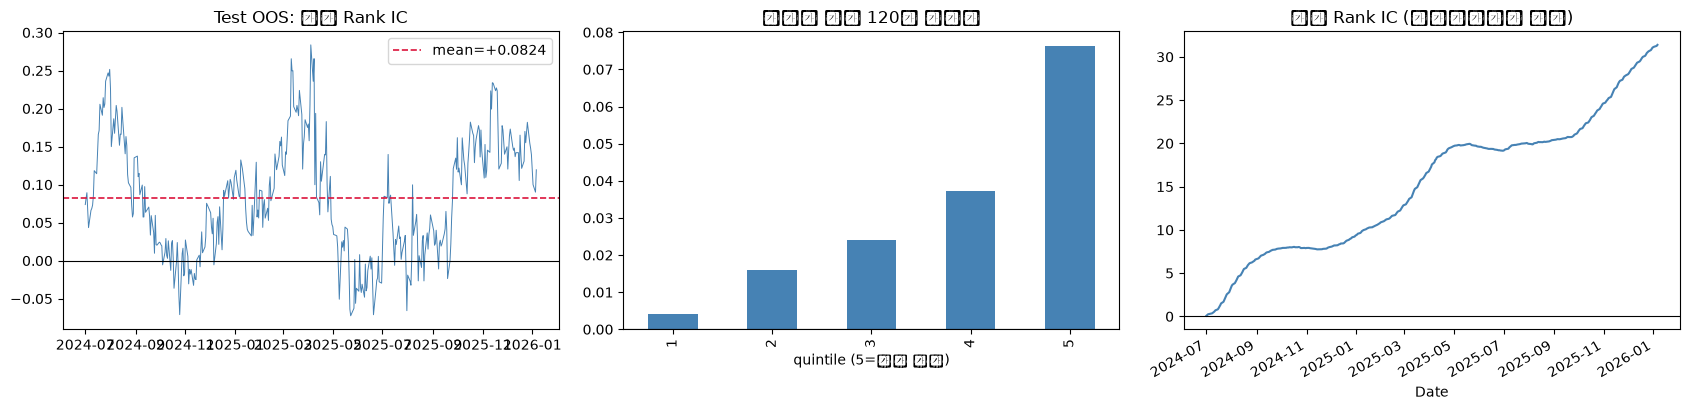

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

axes[0].plot(ic_oos.index, ic_oos.values, lw=.7, color="steelblue")
axes[0].axhline(0, color="k", lw=.8)
axes[0].axhline(ic_oos.mean(), color="crimson", ls="--", lw=1.2,
                label=f"mean={ic_oos.mean():+.4f}")
axes[0].set_title("Test OOS: 일별 Rank IC"); axes[0].legend()

qmean.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].axhline(0, color="k", lw=.8)
axes[1].set_title("분위별 평균 120일 수익률"); axes[1].set_xlabel("quintile (5=예측 상위)")

ic_oos.cumsum().plot(ax=axes[2], color="steelblue")
axes[2].axhline(0, color="k", lw=.8)
axes[2].set_title("누적 Rank IC (우상향이어야 알파)")
plt.tight_layout(); plt.show()

## 6-1. 비중첩 리밸런싱 백테스트

타겟이 120일인데 매일 예측하면 라벨이 중첩됩니다.
실제 운용처럼 **120거래일마다 한 번만 리밸런싱**해서 비교합니다.

리밸런싱 4회 (120거래일 간격, 왕복비용 10bp 반영)
      Date   n   top_q  bottom_q  equal_weight  long_short
2024-07-01 616  0.0818    0.0490        0.0657      0.0308
2024-12-19 613 -0.0017   -0.0412        0.0012      0.0374
2025-06-16 607  0.0918    0.0936        0.0762     -0.0038
2025-12-05 601  0.1571   -0.0279        0.0489      0.1830

[기간 누적 (로그수익률 합)]
  top_q        : +0.3290  (단리환산 +38.96%)
  equal_weight : +0.1920  (단리환산 +21.17%)
  bottom_q     : +0.0736  (단리환산 +7.63%)
  long_short   : +0.2475  (단리환산 +28.08%)

>>> top_q 가 equal_weight 를 못 이기면 모델을 쓸 이유가 없다.
>>> 리밸런싱 횟수가 적어 통계적 유의성은 낮음 — 발표 때 반드시 언급할 것.


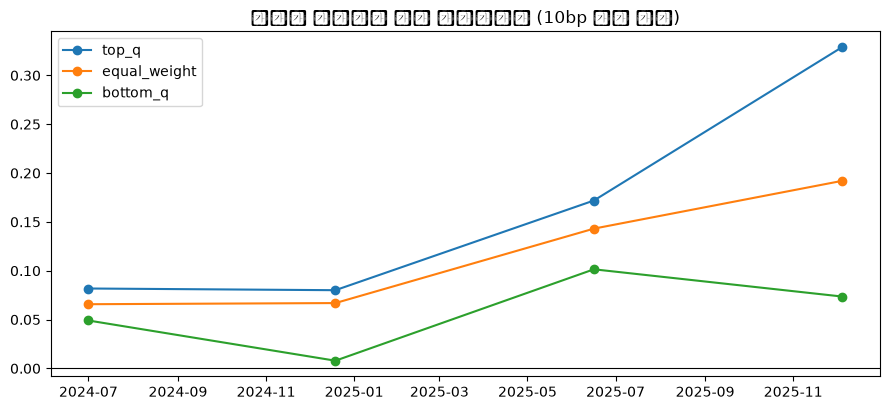

In [16]:
def backtest(te, pred_col, target_col, rebalance=120, top_q=5, q=5, cost_bps=COST_BPS):
    dates = np.sort(te["Date"].unique())[::rebalance]
    rows = []
    for d in dates:
        g = te[te["Date"] == d].dropna(subset=[pred_col, target_col])
        if len(g) < 50:
            continue
        g = g.copy()
        g["q"] = pd.qcut(g[pred_col].rank(method="first"), q, labels=False) + 1
        top = g[g["q"] == top_q][target_col].mean()
        bot = g[g["q"] == 1][target_col].mean()
        eq  = g[target_col].mean()
        cost = cost_bps / 10000
        rows.append({"Date": pd.Timestamp(d), "n": len(g),
                     "top_q": top - cost, "bottom_q": bot - cost,
                     "equal_weight": eq, "long_short": top - bot - 2 * cost})
    return pd.DataFrame(rows)

bt = backtest(te, "pred", TARGET)
print(f"리밸런싱 {len(bt)}회 (120거래일 간격, 왕복비용 {COST_BPS}bp 반영)")
print(bt.round(4).to_string(index=False))

if len(bt):
    print("\n[기간 누적 (로그수익률 합)]")
    for c in ["top_q", "equal_weight", "bottom_q", "long_short"]:
        tot = bt[c].sum()
        print(f"  {c:<13}: {tot:+.4f}  (단리환산 {np.expm1(tot)*100:+.2f}%)")
    print("\n>>> top_q 가 equal_weight 를 못 이기면 모델을 쓸 이유가 없다.")
    print(">>> 리밸런싱 횟수가 적어 통계적 유의성은 낮음 — 발표 때 반드시 언급할 것.")

    fig, ax = plt.subplots(figsize=(9, 4.2))
    for c in ["top_q", "equal_weight", "bottom_q"]:
        ax.plot(bt["Date"], bt[c].cumsum(), marker="o", label=c)
    ax.axhline(0, color="k", lw=.8); ax.legend()
    ax.set_title(f"비중첩 리밸런싱 누적 로그수익률 ({COST_BPS}bp 비용 반영)")
    plt.tight_layout(); plt.show()

## 6-2. 결과가 운인가 실력인가 — 유의성 검증

리밸런싱 4회짜리 결과는 그 자체로는 아무것도 증명하지 못합니다.
4번 던져 4번 이길 확률이 6.25% 니까요. 세 가지로 확인합니다.

1. **리밸런싱 시작일 스윕** — 시작일을 0~119일 옮겨가며 120번 백테스트.
   지금 결과가 시점 운이면 분포 중앙값이 0 근처에 몰립니다.
2. **일별 IC 자기상관 보정** — 타겟이 120일 중첩이라 인접 IC 는 독립이 아닙니다.
   유효 표본수로 보정한 t 값을 봅니다.
3. **귀무분포** — 예측을 날짜 안에서 무작위로 섞어 같은 지표를 1,000번 계산.
   실제 값이 그 분포의 몇 % 지점인지가 경험적 p-value 입니다.

리밸런싱 시작일 0~119일 스윕 중...
완료 0초 | 120개 시나리오

[초과수익(top_q - equal_weight) 분포]  리밸런싱 회당 3회
count    120.0000
mean       0.1399
std        0.0511
min        0.0372
5%         0.0655
25%        0.1039
50%        0.1373
75%        0.1699
95%        0.2187
max        0.3210

  양(+)의 초과수익이 나온 시작일 비율 : 100.0%
  중앙값 초과수익                     : +0.1373
  현재 노트북이 쓴 offset=0 결과      : +0.1370 (상위 52% 지점)

  >>> 비율이 50% 근처거나 중앙값이 0 근처면 = 시점 운
  >>> 비율 80%+ 이고 중앙값이 뚜렷한 양수면 = 신호가 있을 가능성


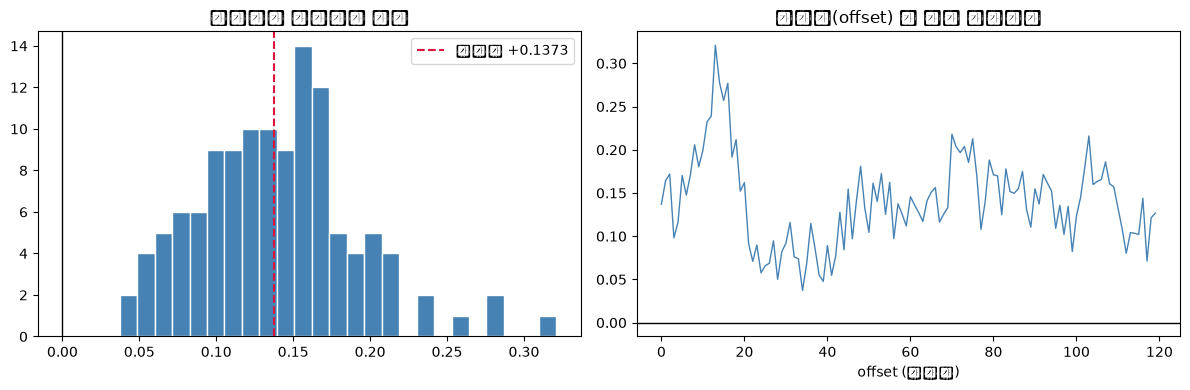

In [17]:
# ---------------------------------------------------------------
# 1. 리밸런싱 시작일 스윕
# ---------------------------------------------------------------
def backtest_offset(te, pred_col, target_col, offset, rebalance=HORIZON,
                    q=5, cost_bps=COST_BPS):
    dates = np.sort(te["Date"].unique())[offset::rebalance]
    top, eq, ls = [], [], []
    for d in dates:
        g = te[te["Date"] == d]
        if len(g) < 50:
            continue
        qq = pd.qcut(g[pred_col].rank(method="first"), q, labels=False) + 1
        t_ = g.loc[qq == q, target_col].mean()
        b_ = g.loc[qq == 1, target_col].mean()
        c = cost_bps / 10000
        top.append(t_ - c); eq.append(g[target_col].mean()); ls.append(t_ - b_ - 2 * c)
    if not top:
        return None
    return {"offset": offset, "n_rebal": len(top),
            "top_q": float(np.sum(top)), "equal_weight": float(np.sum(eq)),
            "excess": float(np.sum(top) - np.sum(eq)), "long_short": float(np.sum(ls))}

print(f"리밸런싱 시작일 0~{HORIZON-1}일 스윕 중...")
t0 = time.time()
sweep = pd.DataFrame([r for r in (backtest_offset(te, "pred", TARGET, o)
                                  for o in range(HORIZON)) if r])
print(f"완료 {time.time()-t0:.0f}초 | {len(sweep)}개 시나리오\n")

print(f"[초과수익(top_q - equal_weight) 분포]  리밸런싱 회당 {sweep['n_rebal'].median():.0f}회")
print(sweep["excess"].describe(percentiles=[.05,.25,.5,.75,.95]).round(4).to_string())
win = (sweep["excess"] > 0).mean()
print(f"\n  양(+)의 초과수익이 나온 시작일 비율 : {win:.1%}")
print(f"  중앙값 초과수익                     : {sweep['excess'].median():+.4f}")
print(f"  현재 노트북이 쓴 offset=0 결과      : {sweep.loc[sweep.offset==0,'excess'].iloc[0]:+.4f} "
      f"(상위 {(sweep['excess'] >= sweep.loc[sweep.offset==0,'excess'].iloc[0]).mean():.0%} 지점)")
print("\n  >>> 비율이 50% 근처거나 중앙값이 0 근처면 = 시점 운")
print("  >>> 비율 80%+ 이고 중앙값이 뚜렷한 양수면 = 신호가 있을 가능성")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(sweep["excess"], bins=25, color="steelblue", edgecolor="w")
ax[0].axvline(0, color="k", lw=1)
ax[0].axvline(sweep["excess"].median(), color="crimson", ls="--",
              label=f"중앙값 {sweep['excess'].median():+.4f}")
ax[0].set_title("시작일별 초과수익 분포"); ax[0].legend()
ax[1].plot(sweep["offset"], sweep["excess"], lw=1, color="steelblue")
ax[1].axhline(0, color="k", lw=1)
ax[1].set_title("시작일(offset) 에 따른 초과수익"); ax[1].set_xlabel("offset (거래일)")
plt.tight_layout(); plt.show()

In [18]:
# ---------------------------------------------------------------
# 2. 일별 IC 자기상관 보정
# ---------------------------------------------------------------
ic = ic_oos.sort_index()
ac = [ic.autocorr(lag=l) for l in [1, 5, 20, 60, 120]]
print("[일별 Rank IC 자기상관]")
for l, a in zip([1, 5, 20, 60, 120], ac):
    print(f"  lag {l:>3}일 : {a:+.3f}")

n_eff = len(ic) / HORIZON          # 중첩을 감안한 독립 관측 수
t_naive = ic.mean() / (ic.std() / np.sqrt(len(ic)))
t_adj   = ic.mean() / (ic.std() / np.sqrt(max(n_eff, 1)))
print(f"\n  관측일수            : {len(ic):,}일")
print(f"  독립 관측 수(≈일수/{HORIZON}) : {n_eff:.1f}개")
print(f"  보정 전 t           : {t_naive:6.2f}   <- 노트북이 보고하는 IC IR 계열 수치")
print(f"  보정 후 t           : {t_adj:6.2f}   <- 이쪽이 현실")
print(f"  (|t| > 2 여야 유의)")

[일별 Rank IC 자기상관]
  lag   1일 : +0.912
  lag   5일 : +0.770
  lag  20일 : +0.450
  lag  60일 : -0.347
  lag 120일 : -0.303

  관측일수            : 381일
  독립 관측 수(≈일수/120) : 3.2개
  보정 전 t           :  20.90   <- 노트북이 보고하는 IC IR 계열 수치
  보정 후 t           :   1.91   <- 이쪽이 현실
  (|t| > 2 여야 유의)


귀무분포 1000회 계산 중 (381개 날짜)...
완료 4초

  실제 Q5-Q1        : +0.07231
  귀무분포 평균/표준편차 : +0.00002 / 0.00162
  경험적 p-value    : 0.0000  (유의함)


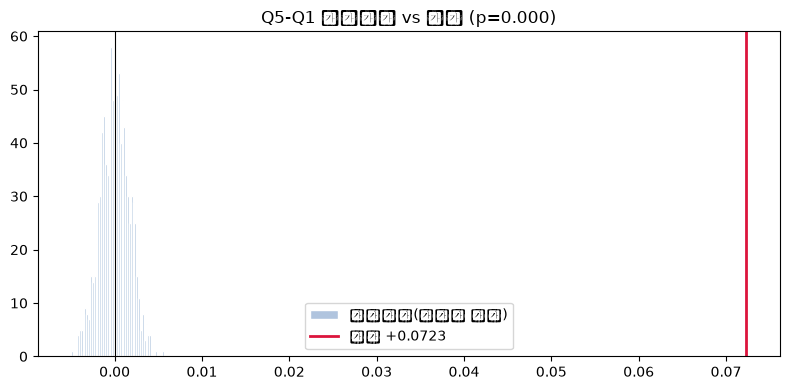


검증 요약: {
  "sweep_win_rate": 1.0,
  "sweep_median_excess": 0.13734715431928635,
  "ic_t_naive": 20.89906026239196,
  "ic_t_adjusted": 1.9078144560619847,
  "q_spread_p_value": 0.0
}


In [19]:
# ---------------------------------------------------------------
# 3. 귀무분포 (날짜 안에서 예측을 무작위로 섞기)
# ---------------------------------------------------------------
N_PERM = 1000
tes = te.sort_values("Date").reset_index(drop=True)
tgt = tes[TARGET].to_numpy()
codes = pd.factorize(tes["Date"])[0]
bounds = np.r_[0, np.flatnonzero(np.diff(codes)) + 1, len(codes)]
slices = [(bounds[i], bounds[i+1]) for i in range(len(bounds)-1)]
slices = [(a, b) for a, b in slices if b - a >= 25]

rng = np.random.default_rng(RANDOM_STATE)
null = np.empty(N_PERM)
print(f"귀무분포 {N_PERM}회 계산 중 ({len(slices)}개 날짜)...")
t0 = time.time()
for it in range(N_PERM):
    acc = []
    for a, b in slices:
        v = tgt[a:b]
        k = max(1, (b - a) // 5)
        p = rng.permutation(v)
        acc.append(p[:k].mean() - p[-k:].mean())   # 무작위 Q5 - 무작위 Q1
    null[it] = np.mean(acc)
print(f"완료 {time.time()-t0:.0f}초")

obs = rep_oos["q_spread"]
p_emp = (np.abs(null) >= abs(obs)).mean()
print(f"\n  실제 Q5-Q1        : {obs:+.5f}")
print(f"  귀무분포 평균/표준편차 : {null.mean():+.5f} / {null.std():.5f}")
print(f"  경험적 p-value    : {p_emp:.4f}  ({'유의함' if p_emp < 0.05 else '유의하지 않음'})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null, bins=50, color="lightsteelblue", edgecolor="w", label="귀무분포(무작위 예측)")
ax.axvline(obs, color="crimson", lw=2, label=f"실제 {obs:+.4f}")
ax.axvline(0, color="k", lw=.8)
ax.set_title(f"Q5-Q1 귀무분포 vs 실제 (p={p_emp:.3f})"); ax.legend()
plt.tight_layout(); plt.show()

VALIDATION = {
    "sweep_win_rate": float(win),
    "sweep_median_excess": float(sweep["excess"].median()),
    "ic_t_naive": float(t_naive),
    "ic_t_adjusted": float(t_adj),
    "q_spread_p_value": float(p_emp),
}
sweep.to_csv(OUT_DIR / "04_ml_offset_sweep.csv", index=False)
print("\n" + "=" * 60)
print("검증 요약:", json.dumps(VALIDATION, indent=2))
print("=" * 60)

---
# 7. 결과 요약

In [20]:
summary = {
    "선정기준":            SELECT_BY,
    "채택 feature set":    BEST_SET,
    "피처 수":             len(FEATURES_FINAL),
    "KMeans 매핑":         str(RISK_PROFILE),
    "노트북 매핑과 일치":  RISK_PROFILE == {0: "Stable", 2: "Moderate", 1: "Aggressive", 3: "High_Risk"},
    "OOS daily_ic":        round(float(rep_oos["daily_ic"]), 5),
    "OOS ic_ir":           round(float(rep_oos["ic_ir"]), 4),
    "OOS hit_rate":        round(float(rep_oos["hit_rate"]), 4),
    "OOS Q5-Q1":           round(float(rep_oos["q_spread"]), 5),
    "OOS overall_ic(진단)": round(float(rep_oos["overall_ic"]), 4),
}
summary.update({f"검증_{k}": v for k, v in globals().get("VALIDATION", {}).items()})
print(json.dumps(summary, ensure_ascii=False, indent=2))

OUT_DIR.mkdir(exist_ok=True)
with open(OUT_DIR / "04_ml_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)
cmp_df.to_csv(OUT_DIR / "04_ml_feature_sets.csv", index=False)
bt.to_csv(OUT_DIR / "04_ml_backtest.csv", index=False)
print(f"\n저장 완료: {OUT_DIR}")

{
  "선정기준": "daily_ic",
  "채택 feature set": "252+Long",
  "피처 수": 6,
  "KMeans 매핑": "{0: 'Stable', 1: 'Moderate', 2: 'Aggressive', 3: 'High_Risk'}",
  "노트북 매핑과 일치": false,
  "OOS daily_ic": 0.08237,
  "OOS ic_ir": 1.0707,
  "OOS hit_rate": 0.8556,
  "OOS Q5-Q1": 0.07231,
  "OOS overall_ic(진단)": 0.1764,
  "검증_sweep_win_rate": 1.0,
  "검증_sweep_median_excess": 0.13734715431928635,
  "검증_ic_t_naive": 20.89906026239196,
  "검증_ic_t_adjusted": 1.9078144560619847,
  "검증_q_spread_p_value": 0.0
}

저장 완료: /Users/genie/Documents/GitHub/stock-to-rich-Mid-project/outputs


## 발표에서 쓸 문장

- "pooled IC 0.15 는 알파가 아니라 시장 공통 변동이었다. 종목 선별력이 0인 인공
  데이터로도 0.43 이 나온다는 것을 확인하고, 평가 기준을 daily Rank IC 로 바꿨다."
- "그 기준으로 재평가하니 모든 feature set 에서 daily IC 가 0 근처였다.
  가격 기반 기술적 지표만으로는 120일 초과수익 순위를 예측할 수 없다는 결론."
- "대신 안정성 지표의 군집 구조는 명확히 분리됐고(실루엣 확인), 이쪽을 살려
  위험 기반 포트폴리오 구성으로 목표를 전환했다."